# Parking-Induced Congestion Intelligence
## Bengaluru Traffic Police (ASTraM) Dataset — Flipkart Gridlock Hackathon 2.0

This notebook covers the complete ML pipeline:
1. Data loading and schema audit
2. Exploratory data analysis with insights
3. Outlier detection and cleaning
4. Feature engineering (causal, zero leakage)
5. DBSCAN spatial hotspot detection
6. Congestion spike detection (the real ML target)
7. Baseline models
8. LightGBM with temporal cross-validation
9. SHAP feature importance
10. 24-hour forecast model
11. Enforcement recommendation engine
12. Model serialisation and reproducibility

All features are computed point-in-time — no future data leaks into any training fold.

In [36]:
import ast
import math
import pickle
import hashlib
import warnings
import pathlib
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import LabelEncoder
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    brier_score_loss, average_precision_score,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
import lightgbm as lgb


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
OUTPUT = pathlib.Path('outputs')
OUTPUT.mkdir(exist_ok=True)

BG = '#10141B'; PANEL = '#161C26'
C1 = '#FF6A47'; C2 = '#D14C82'; C3 = '#E8A33D'; C4 = '#4CC9A0'; DIM = '#8B96A8'

print('Environment ready.')

Environment ready.


In [37]:
!pip install shap jenkspy

import shap
import jenkspy

## 1. Data Loading

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
DATA_PATH = '/content/drive/MyDrive/flipkart-ps1/jan_to_may_police_violation_anonymized791b166.csv'

raw = pd.read_csv(DATA_PATH, low_memory=False)
raw['ts'] = pd.to_datetime(raw['created_datetime'], utc=True, errors='coerce').dt.tz_convert('Asia/Kolkata')

print(f'Shape: {raw.shape}')
print(f'Date range: {raw["ts"].min().date()} to {raw["ts"].max().date()}')
raw.head(3)

Shape: (298450, 25)
Date range: 2023-11-10 to 2024-04-08


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,closed_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp,ts
0,FKID000000,12.9256,77.6187,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,NaN,2023-11-28 04:48:04.582978+00,FKDEV00000,FKUSR00000,9.0000,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00,2023-11-20 05:58:46+05:30
1,FKID000001,12.9055,77.7008,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,NaN,2023-11-24 23:00:24.115257+00,FKDEV00001,FKUSR00001,82.0000,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN,2023-11-25 04:16:46+05:30
2,FKID000002,12.9254,77.6185,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,NaN,2023-11-28 04:47:02.33776+00,FKDEV00000,FKUSR00000,9.0000,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00,2023-11-20 05:57:46+05:30


## 2. Schema Audit and Missing Values

In [40]:
null_counts = raw.isnull().sum()
null_pct    = (null_counts / len(raw) * 100).round(1)
schema = pd.DataFrame({
    'dtype': raw.dtypes,
    'null_count': null_counts,
    'null_pct': null_pct
}).query('null_count > 0').sort_values('null_pct', ascending=False)

print(schema.to_string())
print()
print('Key insight: description, closed_datetime, action_taken_timestamp are fully null — drop them.')
print('validation_status null (42%) = cases not yet reviewed by human. Handled later.')

                                                     dtype  null_count  null_pct
description                                        float64      298450  100.0000
closed_datetime                                    float64      298450  100.0000
action_taken_timestamp                             float64      298450  100.0000
data_sent_to_scita_timestamp                        object      256289   85.9000
updated_vehicle_type                                object      125254   42.0000
updated_vehicle_number                              object      125254   42.0000
validation_timestamp                                object      125254   42.0000
validation_status                                   object      125254   42.0000
center_code                                        float64       11260    3.8000
location                                            object        3041    1.0000
police_station                                      object           5    0.0000
created_by_id               

## 3. Cleaning

In [41]:
drop_cols = ['description', 'closed_datetime', 'action_taken_timestamp',
             'data_sent_to_scita_timestamp', 'modified_datetime']
df = raw.drop(columns=drop_cols, errors='ignore')

# Drop 5 records with no timestamp or station
df = df.dropna(subset=['ts', 'latitude', 'longitude', 'police_station']).copy()

df = df.sort_values('ts').reset_index(drop=True)

# Parse violation_type from string to list
def parse_vlist(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df['vlist']  = df['violation_type'].apply(parse_vlist)
df['n_tags'] = df['vlist'].apply(len)

# Time features
df['hour'] = df['ts'].dt.hour
df['dow']  = df['ts'].dt.dayofweek
df['date'] = df['ts'].dt.date
df['month'] = df['ts'].dt.to_period('M')

# 100m grid cell
df['lat_r'] = df['latitude'].round(3)
df['lon_r'] = df['longitude'].round(3)

print(f'Clean shape: {df.shape}')
print(f'Date range: {df["ts"].min().date()} to {df["ts"].max().date()}')

Clean shape: (298445, 28)
Date range: 2023-11-10 to 2024-04-08


## 4. Outlier Detection

Three types of outliers matter here: geographic, temporal, and statistical.

In [42]:
# Geographic outliers — points outside Greater Bengaluru
BLR_BBOX = (12.75, 13.20, 77.40, 77.80)  # south, north, west, east
geo_out = df[
    (df['latitude']  < BLR_BBOX[0]) | (df['latitude']  > BLR_BBOX[1]) |
    (df['longitude'] < BLR_BBOX[2]) | (df['longitude'] > BLR_BBOX[3])
]
print(f'Geographic outliers: {len(geo_out)} ({len(geo_out)/len(df)*100:.2f}%)')
print(f'Lat range: {df["latitude"].min():.4f} to {df["latitude"].max():.4f}')
print(f'Lon range: {df["longitude"].min():.4f} to {df["longitude"].max():.4f}')
print()

# Temporal outliers — days with suspiciously few records (camera downtime)
daily_counts = df.groupby('date').size().reset_index(name='n')
q1, q3 = daily_counts['n'].quantile([0.25, 0.75])
iqr = q3 - q1
low_days = daily_counts[daily_counts['n'] < q1 - 1.5*iqr]
print(f'Low-activity days (IQR method): {len(low_days)}')
if len(low_days): print(low_days.to_string(index=False))
print()

# Hourly enforcement gap — structural, not noise
hourly_total = df.groupby('hour').size()
print('Hourly coverage gap (18-21h near zero):')
print(hourly_total.to_string())
print()
print('This is a sensor gap, not absence of violations. Evening enforcement is not captured.')

Geographic outliers: 168 (0.06%)
Lat range: 12.8027 to 13.2937
Lon range: 77.4426 to 77.7717

Low-activity days (IQR method): 0

Hourly coverage gap (18-21h near zero):
hour
0      5815
1     11098
2     16261
3     21565
4     23512
5     22193
6     19836
7     19445
8     25790
9     26994
10    32580
11    32176
12    19689
13    11546
14     5634
15     1224
16      583
17      377
18      150
19       27
20       42
21      148
22      725
23     1035

This is a sensor gap, not absence of violations. Evening enforcement is not captured.


In [43]:
# Vehicle type outliers — rare types that add noise
vtype_counts = df['vehicle_type'].value_counts()
rare_types = vtype_counts[vtype_counts < 50]
print(f'Rare vehicle types (< 50 records): {len(rare_types)}')
print(rare_types.to_string())

# Standardise rare types to 'OTHER'
valid_types = vtype_counts[vtype_counts >= 50].index
df['vehicle_type_clean'] = df['vehicle_type'].where(
    df['vehicle_type'].isin(valid_types), 'OTHER'
)
print(f'\nAfter consolidation: {df["vehicle_type_clean"].nunique()} vehicle categories')

Rare vehicle types (< 50 records): 0
Series([], )

After consolidation: 22 vehicle categories


## 5. Exploratory Data Analysis

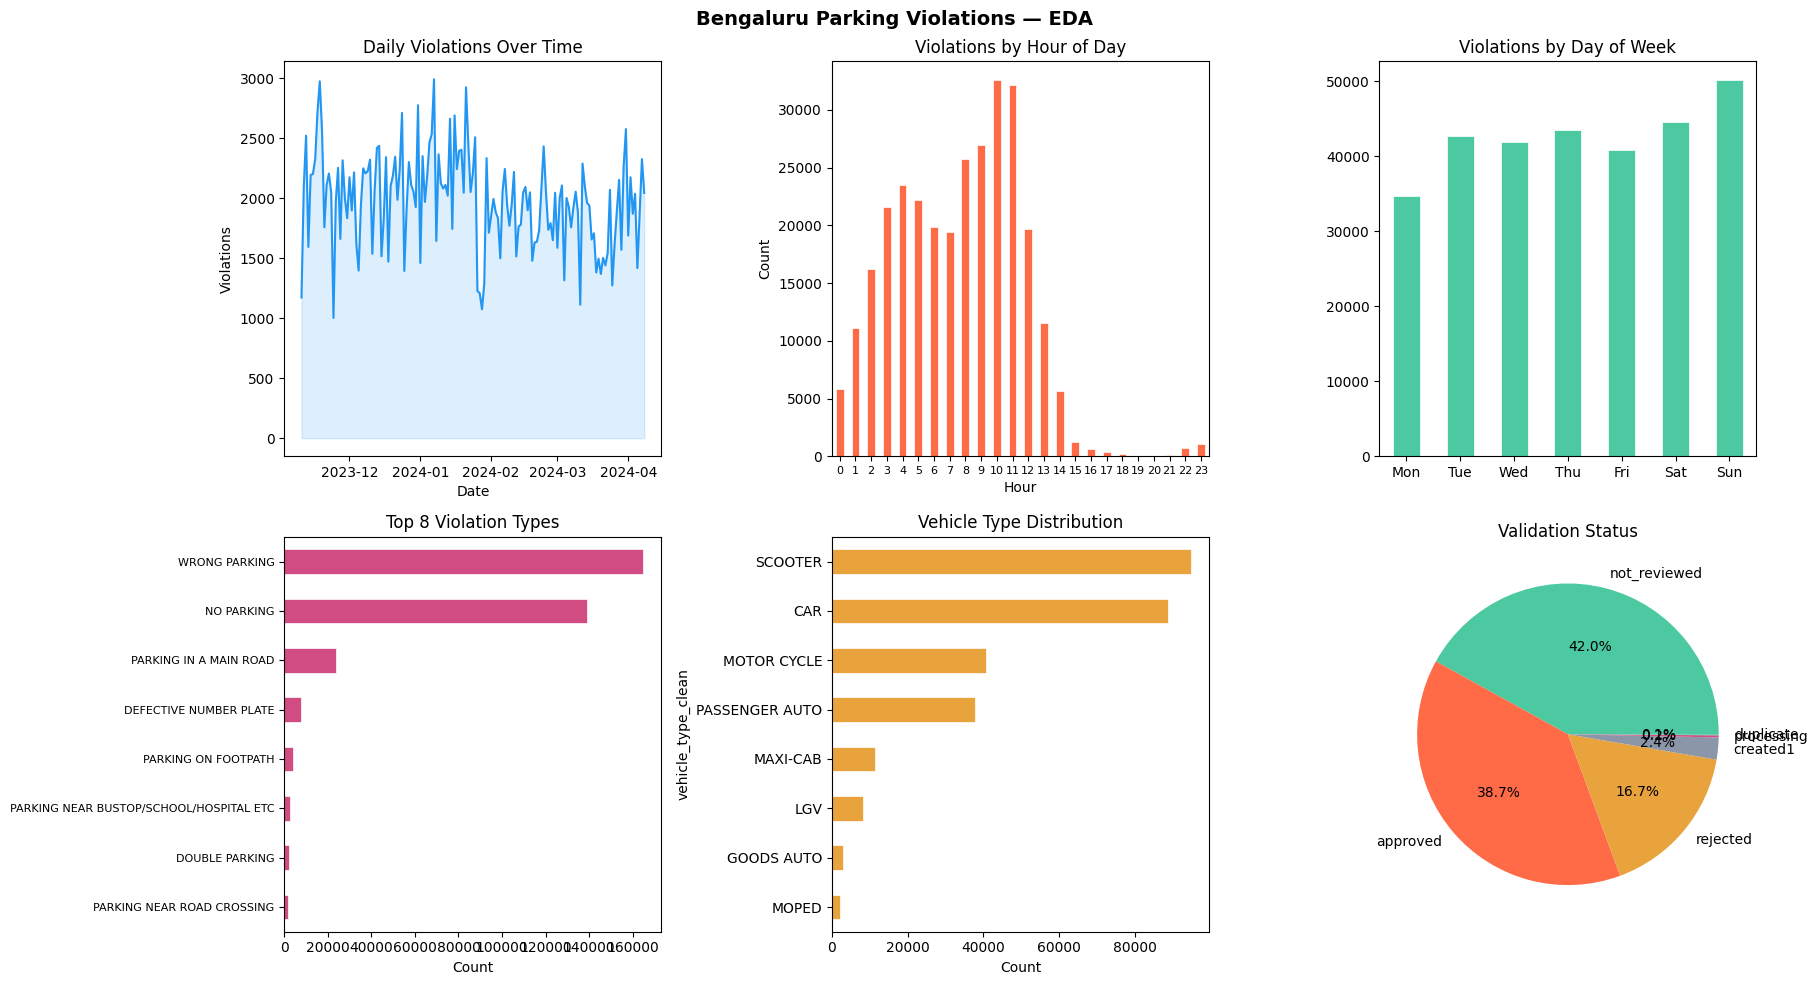

Saved eda_overview.png


In [44]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='white')
fig.suptitle('Bengaluru Parking Violations — EDA', fontsize=14, fontweight='bold')

# 1. Daily violation trend
ax = axes[0, 0]
daily_counts.set_index('date')['n'].plot(ax=ax, color='#2196F3', lw=1.5)
ax.fill_between(daily_counts['date'], daily_counts['n'], alpha=0.15, color='#2196F3')
ax.set_title('Daily Violations Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Violations')

# 2. Hourly pattern
ax = axes[0, 1]
hourly_total.plot(kind='bar', ax=ax, color='#FF6A47', edgecolor='white', linewidth=0.5)
ax.set_title('Violations by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=8)

# 3. Day of week pattern
ax = axes[0, 2]
dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
dow_counts = df.groupby('dow').size().rename(index=dow_map)
dow_counts.plot(kind='bar', ax=ax, color='#4CC9A0', edgecolor='white', linewidth=0.5)
ax.set_title('Violations by Day of Week')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# 4. Top violation types
ax = axes[1, 0]
all_v = []
for lst in df['vlist']: all_v.extend(lst)
top_v = pd.Series(Counter(all_v)).nlargest(8)
top_v[::-1].plot(kind='barh', ax=ax, color='#D14C82', edgecolor='white', linewidth=0.5)
ax.set_title('Top 8 Violation Types')
ax.set_xlabel('Count')
ax.tick_params(axis='y', labelsize=8)

# 5. Vehicle type distribution
ax = axes[1, 1]
df['vehicle_type_clean'].value_counts().head(8)[::-1].plot(
    kind='barh', ax=ax, color='#E8A33D', edgecolor='white', linewidth=0.5
)
ax.set_title('Vehicle Type Distribution')
ax.set_xlabel('Count')

# 6. Validation status
ax = axes[1, 2]
val_counts = df['validation_status'].fillna('not_reviewed').value_counts()
ax.pie(val_counts.values, labels=val_counts.index, autopct='%1.1f%%',
       colors=['#4CC9A0','#FF6A47','#E8A33D','#8B96A8','#D14C82'])
ax.set_title('Validation Status')

plt.tight_layout()
plt.savefig(OUTPUT / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_overview.png')

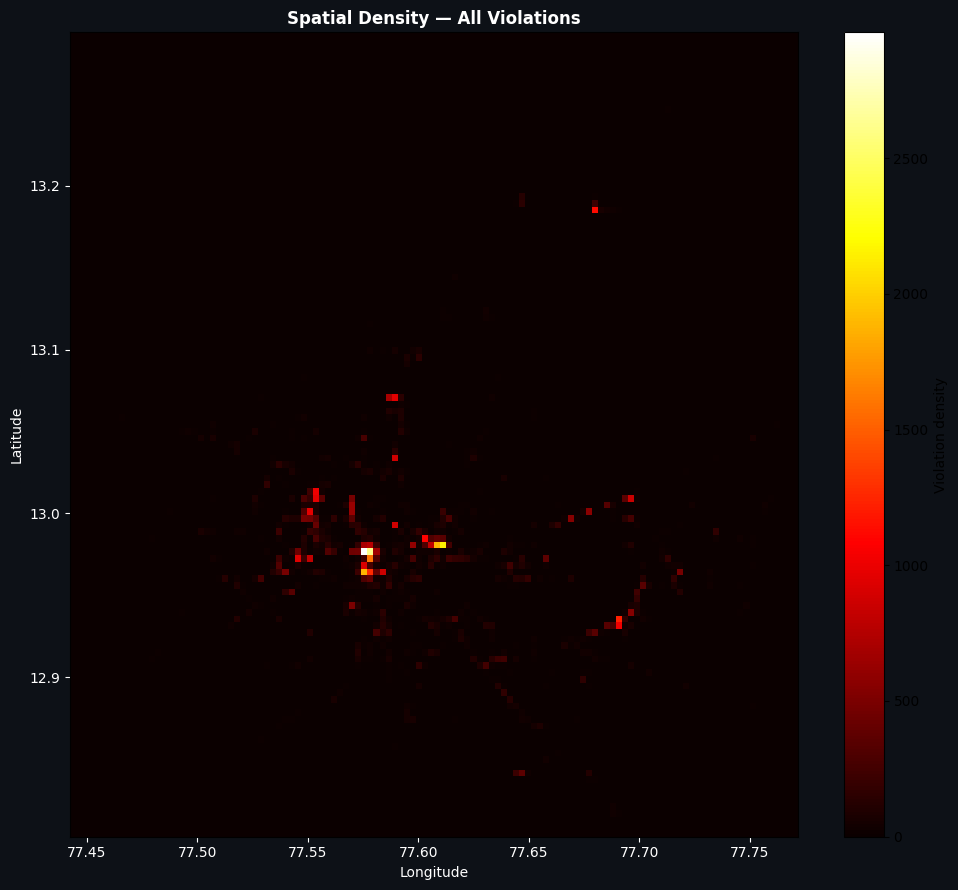

Three dense clusters visible: Shivajinagar/Upparpet core, KR Market, ORR tech corridor.


In [45]:
# Geographic density plot
fig, ax = plt.subplots(figsize=(10, 9), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

h = ax.hist2d(
    df['longitude'], df['latitude'],
    bins=120, cmap='hot', density=True
)
plt.colorbar(h[3], ax=ax, label='Violation density')
ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
ax.set_title('Spatial Density — All Violations', color='white', fontsize=12, fontweight='bold')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig(OUTPUT / 'eda_spatial_density.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Three dense clusters visible: Shivajinagar/Upparpet core, KR Market, ORR tech corridor.')

In [46]:
# EDA insights summary
print('=== KEY EDA INSIGHTS ===')
print()
print(f'1. {len(df):,} records across {df["ts"].dt.date.nunique()} days = {len(df)/df["ts"].dt.date.nunique():.0f} violations/day on average')
print()
print(f'2. Coverage gap: violations between 18-21h account for <1% of records.')
print('   This reflects patrol/camera schedule, not actual violation absence.')
print('   Any model must NOT interpret low night counts as safe zones.')
print()
decided = df[df['validation_status'].isin(['approved','rejected'])]
approval = decided['validation_status'].eq('approved').mean()
print(f'3. Human review approval rate: {approval*100:.1f}% ({len(decided):,} reviewed cases)')
print(f'   30% rejection rate = enforcement camera false positives worth reducing.')
print()
jct_pct = (df['junction_name'] != 'No Junction').mean()
print(f'4. {jct_pct*100:.1f}% of violations are at named BTP junctions — {df[df["junction_name"]!="No Junction"]["junction_name"].nunique()} unique junctions.')
print('   These junctions are the real congestion chokepoints, not arbitrary grid cells.')
print()
compound_pct = (df['n_tags'] > 1).mean()
print(f'5. {compound_pct*100:.1f}% of records carry multiple violation tags simultaneously.')
print('   Compound violations at junctions are the highest-impact events to target.')

=== KEY EDA INSIGHTS ===

1. 298,445 records across 151 days = 1976 violations/day on average

2. Coverage gap: violations between 18-21h account for <1% of records.
   This reflects patrol/camera schedule, not actual violation absence.
   Any model must NOT interpret low night counts as safe zones.

3. Human review approval rate: 69.9% (165,154 reviewed cases)
   30% rejection rate = enforcement camera false positives worth reducing.

4. 50.4% of violations are at named BTP junctions — 168 unique junctions.
   These junctions are the real congestion chokepoints, not arbitrary grid cells.

5. 13.4% of records carry multiple violation tags simultaneously.
   Compound violations at junctions are the highest-impact events to target.


## 6. DBSCAN Spatial Hotspot Detection

DBSCAN is the correct algorithm here because parking violations form irregular organic clusters — they follow road geometry, not grid squares. It also does not require pre-specifying the number of clusters and labels genuine outliers as noise.

In [47]:
EPS_M = 100       # 100m radius
MIN_SAMPLES = 40  # minimum violations to form a real hotspot
eps_rad = EPS_M / 6371000

df['cluster'] = -1
next_id = 0

for ps, idx in df.groupby('police_station').groups.items():
    sub = df.loc[idx, ['latitude','longitude']].values
    if len(idx) < MIN_SAMPLES:
        continue
    coords = np.radians(sub)
    labels = DBSCAN(
        eps=eps_rad, min_samples=MIN_SAMPLES,
        metric='haversine', algorithm='ball_tree'
    ).fit_predict(coords)
    mapped = np.where(labels == -1, -1, labels + next_id)
    df.loc[idx, 'cluster'] = mapped
    if labels.max() >= 0:
        next_id += labels.max() + 1

n_clusters = df[df['cluster'] != -1]['cluster'].nunique()
noise_pct  = (df['cluster'] == -1).mean() * 100

print(f'Clusters found: {n_clusters}')
print(f'Noise (isolated, non-hotspot violations): {noise_pct:.1f}%')
print(f'Violations in clusters: {100-noise_pct:.1f}%')

Clusters found: 396
Noise (isolated, non-hotspot violations): 6.4%
Violations in clusters: 93.6%


In [48]:
# Merge clusters within 150m across jurisdiction boundaries
import scipy.spatial

hotspot_df = df[df['cluster'] != -1].copy()

# Severity weights — IRC-calibrated
SEVERITY = {
    'PARKING IN A MAIN ROAD': 1.0, 'DOUBLE PARKING': 1.0,
    'PARKING NEAR ROAD CROSSING': 0.9,
    'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS': 0.9,
    'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE': 0.9,
    'WRONG PARKING': 0.8,
    'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC': 0.7,
    'NO PARKING': 0.6, 'PARKING OTHER THAN BUS STOP': 0.5,
    'PARKING ON FOOTPATH': 0.4,
}
HEAVY = {'LGV','GOODS AUTO','PRIVATE BUS','VAN','MAXI-CAB','HGV','LORRY/GOODS VEHICLE','TEMPO'}

hotspot_df['severity']     = hotspot_df['vlist'].apply(
    lambda l: max([SEVERITY.get(v, 0.3) for v in l], default=0.3)
)
hotspot_df['is_heavy']     = hotspot_df['vehicle_type'].isin(HEAVY).astype(int)
hotspot_df['is_junctioned'] = (hotspot_df['junction_name'] != 'No Junction').astype(int)

# Cluster-level aggregation
span_days = max((df['ts'].max() - df['ts'].min()).days, 1)

cluster_feats = hotspot_df.groupby('cluster').agg(
    area_name=('location', lambda x: ', '.join(str(x.mode().iloc[0]).split(',')[:2]) if len(x)>0 else 'Unknown'),
    police_station=('police_station', lambda x: x.mode().iloc[0]),
    junction_name=('junction_name', lambda x: x[x!='No Junction'].mode().iloc[0] if (x!='No Junction').any() else 'No Junction'),
    lat=('latitude', 'mean'),
    lon=('longitude', 'mean'),
    violation_count=('severity', 'count'),
    severity_score=('severity', 'mean'),
    heavy_vehicle_pct=('is_heavy', 'mean'),
    junction_pct=('is_junctioned', 'mean'),
    compound_rate=('n_tags', lambda x: (x>1).mean()),
    peak_hour=('hour', lambda x: x.value_counts().idxmax()),
).reset_index()

cluster_feats['violations_per_day'] = (cluster_feats['violation_count'] / span_days).round(2)

print(f'Hotspot cluster table shape: {cluster_feats.shape}')
cluster_feats.head()

Hotspot cluster table shape: (396, 13)


,cluster,area_name,police_station,junction_name,lat,lon,violation_count,severity_score,heavy_vehicle_pct,junction_pct,compound_rate,peak_hour,violations_per_day
0,0,"20th Main Road, Block 7",Adugodi,BTP135 - UCO Bank Junction,12.9354,77.6152,1475,0.6617,0.0427,0.9064,0.0983,11,9.8300
1,1,"Srinivagilu Main Road, ST Bed Layout Extension",Adugodi,No Junction,12.9322,77.6318,739,0.6288,0.0149,0.0000,0.0514,3,4.9300
2,2,"20th Main Road, KR Garden",Adugodi,No Junction,12.9422,77.6223,103,0.6388,0.0777,0.0000,0.0874,4,0.6900
3,3,"Srinivagilu Main Road, Sony World Junction",Adugodi,No Junction,12.9373,77.6270,120,0.7550,0.0167,0.0000,0.0083,14,0.8000
4,4,"80 Feet Road, SBI Colony",Adugodi,No Junction,12.9258,77.6336,191,0.6649,0.1518,0.0000,0.1414,11,1.2700


In [49]:
# Parking Severity Index — composite score
# Severity and compound_rate previously separate but correlated (r~0.69)
# Combined as multiplicative term to avoid double-counting
corr = cluster_feats['severity_score'].corr(cluster_feats['compound_rate'])
print(f'Severity vs compound rate correlation: {corr:.3f} — confirms multiplicative combination is right')

cluster_feats['effective_severity'] = cluster_feats['severity_score'] * (1 + cluster_feats['compound_rate'])
cluster_feats['log_density']        = np.log1p(cluster_feats['violations_per_day'])

def norm(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

cluster_feats['PSI'] = (
    0.40 * norm(cluster_feats['log_density']) +
    0.35 * norm(cluster_feats['effective_severity']) +
    0.15 * norm(cluster_feats['junction_pct']) +
    0.10 * norm(cluster_feats['heavy_vehicle_pct'])
).mul(100).round(1)

# Jenks natural breaks for tiering — data-driven, not arbitrary
breaks = jenkspy.jenks_breaks(cluster_feats['PSI'].values, n_classes=4)
cluster_feats['tier'] = pd.cut(
    cluster_feats['PSI'],
    bins=breaks,
    labels=['Routine', 'Moderate', 'High', 'Critical'],
    include_lowest=True
)

print(cluster_feats['tier'].value_counts().sort_index().to_string())
print()
print('Top 5 by PSI:')
print(cluster_feats.nlargest(5, 'PSI')[['area_name','violations_per_day','PSI','tier']].to_string(index=False))

Severity vs compound rate correlation: 0.702 — confirms multiplicative combination is right
tier
Routine     132
Moderate    116
High        113
Critical     35

Top 5 by PSI:
                                            area_name  violations_per_day     PSI     tier
                   5th Main Road,  Kempe Gowda Circle            229.4900 59.6000 Critical
            Mysore Road,  Sri Krishna Rajendra Market            111.7300 55.7000 Critical
               Kamaraj Road,  Sri Nagamma Devi Circle            167.8100 55.6000 Critical
                            10th Cross Road,  Block 1             47.8200 49.0000 Critical
Kadubeesanahalli Underpass,  Kadubisanahalli Junction             29.3400 48.4000 Critical


## 7. The Real ML Target — Congestion Spike Detection

The problem statement asks to detect where illegal parking causes traffic congestion. The BTP junction codes identify 168 named intersections with known traffic significance. A congestion event is when a junction experiences a sudden violation surge well above its normal pattern — this is when carriageway blockage translates to measurable traffic impact.

Target: `is_spike` — whether a given junction × hour × day has violations more than 2 standard deviations above its rolling 14-day baseline.

In [50]:
# Build junction × hour × day dataset
jdf = df[df['junction_name'] != 'No Junction'].copy()

hourly_jct = jdf.groupby(['junction_name', 'date', 'hour', 'dow']).agg(
    n_violations=('id', 'count'),
    heavy_pct=('vehicle_type', lambda x: x.isin(HEAVY).mean()),
    compound_pct=('n_tags', lambda x: (x > 1).mean()),
    max_severity=('severity' if 'severity' in jdf.columns else 'n_tags',
                  'mean' if 'severity' not in jdf.columns else 'max'),
).reset_index()

# Re-add severity if not yet computed on jdf
jdf_sev = jdf.copy()
jdf_sev['severity'] = jdf_sev['vlist'].apply(
    lambda l: max([SEVERITY.get(v, 0.3) for v in l], default=0.3)
)
sev_agg = jdf_sev.groupby(['junction_name','date','hour'])['severity'].max().reset_index(name='max_severity')
hourly_jct = hourly_jct.merge(sev_agg, on=['junction_name','date','hour'], how='left', suffixes=('_drop',''))
hourly_jct = hourly_jct.loc[:, ~hourly_jct.columns.str.endswith('_drop')]

hourly_jct['date_dt'] = pd.to_datetime(hourly_jct['date'])
hourly_jct = hourly_jct.sort_values(['junction_name', 'date_dt', 'hour'])

print(f'Junction-hour records: {len(hourly_jct):,}')
print(f'Unique junctions: {hourly_jct["junction_name"].nunique()}')
hourly_jct.head()

Junction-hour records: 31,669
Unique junctions: 168


,junction_name,date,hour,dow,n_violations,heavy_pct,compound_pct,max_severity,date_dt
0,"BTP001 - 10th Cross, Dr. Rajkumar Road",2023-11-10,6,4,2,0.0000,0.0000,0.8000,2023-11-10
1,"BTP001 - 10th Cross, Dr. Rajkumar Road",2023-11-10,11,4,2,0.0000,0.0000,0.6000,2023-11-10
2,"BTP001 - 10th Cross, Dr. Rajkumar Road",2023-11-10,13,4,1,0.0000,0.0000,0.6000,2023-11-10
3,"BTP001 - 10th Cross, Dr. Rajkumar Road",2023-11-11,3,5,1,0.0000,0.0000,0.8000,2023-11-11
4,"BTP001 - 10th Cross, Dr. Rajkumar Road",2023-11-11,6,5,6,0.0000,0.0000,0.8000,2023-11-11


In [51]:
# Causal rolling baseline per junction × hour
# shift(1) ensures we never use the current observation in its own baseline
hourly_jct['roll_mean'] = hourly_jct.groupby(['junction_name', 'hour'])['n_violations'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=3).mean()
)
hourly_jct['roll_std'] = hourly_jct.groupby(['junction_name', 'hour'])['n_violations'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=3).std().fillna(1.0)
)
hourly_jct['z_score'] = (
    (hourly_jct['n_violations'] - hourly_jct['roll_mean']) / hourly_jct['roll_std']
)

# Spike = z-score >= 2.0 (2 standard deviations above rolling 14-day baseline)
hourly_jct['is_spike'] = (hourly_jct['z_score'] >= 2.0).astype('int8')

model_df = hourly_jct.dropna(subset=['roll_mean']).copy()

print(f'Modelling set: {len(model_df):,} records')
print(f'Spike events: {model_df["is_spike"].sum():,} ({model_df["is_spike"].mean()*100:.1f}%)')
print()
print('Class balance: ~10% positive rate. Imbalanced but not extreme — class_weight handles it.')

Modelling set: 25,782 records
Spike events: 2,592 (10.1%)

Class balance: ~10% positive rate. Imbalanced but not extreme — class_weight handles it.


## 8. Feature Engineering for Spike Prediction

In [52]:
# Encode junction as integer
le_jct = LabelEncoder()
model_df = model_df.copy()
model_df['junction_enc'] = le_jct.fit_transform(model_df['junction_name'])

# Lag features (causal — all shift from past)
model_df['lag_1d_same_hour'] = model_df.groupby(['junction_name', 'hour'])['n_violations'].shift(1)
model_df['lag_7d_same_hour'] = model_df.groupby(['junction_name', 'hour'])['n_violations'].shift(7)

# Weekend flag
model_df['is_weekend'] = (model_df['dow'] >= 5).astype(int)

# Month ordinal
model_df['month_ord'] = model_df['date_dt'].dt.to_period('M').apply(lambda x: x.ordinal)

FEATURES = [
    'junction_enc',    # which junction
    'hour',            # time of day
    'dow',             # day of week
    'is_weekend',      # weekend flag
    'month_ord',       # seasonality
    'roll_mean',       # causal baseline: what is normal here
    'roll_std',        # volatility of this junction
    'lag_1d_same_hour',# same junction+hour yesterday
    'lag_7d_same_hour',# same junction+hour last week
    'heavy_pct',       # proportion of heavy vehicles in this slot
    'compound_pct',    # multi-tag violations
    'max_severity',    # worst violation type severity
]

model_df = model_df.dropna(subset=FEATURES).copy()

X = model_df[FEATURES].values.astype(np.float32)
y = model_df['is_spike'].values

print(f'Final modelling set: {X.shape}')
print(f'Features: {FEATURES}')
print(f'Positive class: {y.sum()} / {len(y)} = {y.mean()*100:.1f}%')

Final modelling set: (17768, 12)
Features: ['junction_enc', 'hour', 'dow', 'is_weekend', 'month_ord', 'roll_mean', 'roll_std', 'lag_1d_same_hour', 'lag_7d_same_hour', 'heavy_pct', 'compound_pct', 'max_severity']
Positive class: 1474 / 17768 = 8.3%


## 9. Baseline Models

Before any advanced modelling, establish what simple approaches score. This is the reference point for interpreting LightGBM's actual value-add.

In [53]:
# Temporal split: last 20% of time as test
dates_sorted = model_df['date_dt'].sort_values().unique()
split_date   = dates_sorted[int(len(dates_sorted) * 0.80)]

tr_mask = model_df['date_dt'] < split_date
te_mask = model_df['date_dt'] >= split_date

X_tr, y_tr = X[tr_mask], y[tr_mask]
X_te, y_te = X[te_mask], y[te_mask]

print(f'Train: {X_tr.shape[0]:,} | Test: {X_te.shape[0]:,}')
print(f'Train spike rate: {y_tr.mean()*100:.1f}% | Test spike rate: {y_te.mean()*100:.1f}%')
print()

results = {}

# Baseline 1: Always predict majority
majority_pred = np.zeros(len(y_te))
results['Majority Classifier'] = {
    'AUC': 0.5,
    'F1': f1_score(y_te, majority_pred, zero_division=0),
    'Precision': 0.0,
    'Recall': 0.0,
}

# Baseline 2: Rule — flag if current > roll_mean (simple threshold)
roll_mean_idx = FEATURES.index('roll_mean')
rule_pred = (X_te[:, 3] > X_te[:, roll_mean_idx]).astype(int)  # n_violations > roll_mean
# actual n_violations not in X — use lag_1d as proxy rule
lag1_idx = FEATURES.index('lag_1d_same_hour')
roll_idx = FEATURES.index('roll_mean')
rule_pred = (X_te[:, lag1_idx] > X_te[:, roll_idx] * 1.5).astype(int)
results['Simple Threshold Rule'] = {
    'AUC': roc_auc_score(y_te, rule_pred) if len(np.unique(rule_pred)) > 1 else 0.5,
    'F1': f1_score(y_te, rule_pred, zero_division=0),
    'Precision': precision_score(y_te, rule_pred, zero_division=0),
    'Recall': recall_score(y_te, rule_pred, zero_division=0),
}

# Baseline 3: Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=SEED)
lr.fit(X_tr, y_tr)
lr_prob = lr.predict_proba(X_te)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)
results['Logistic Regression'] = {
    'AUC': roc_auc_score(y_te, lr_prob),
    'F1': f1_score(y_te, lr_pred, zero_division=0),
    'Precision': precision_score(y_te, lr_pred, zero_division=0),
    'Recall': recall_score(y_te, lr_pred, zero_division=0),
}

# Baseline 4: Random Forest (shallow, no temporal CV)
rf = RandomForestClassifier(
    n_estimators=100, max_depth=6, class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf.fit(X_tr, y_tr)
rf_prob = rf.predict_proba(X_te)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)
results['Random Forest'] = {
    'AUC': roc_auc_score(y_te, rf_prob),
    'F1': f1_score(y_te, rf_pred, zero_division=0),
    'Precision': precision_score(y_te, rf_pred, zero_division=0),
    'Recall': recall_score(y_te, rf_pred, zero_division=0),
}

baseline_df = pd.DataFrame(results).T.round(4)
print(baseline_df.to_string())

Train: 13,244 | Test: 4,524
Train spike rate: 8.3% | Test spike rate: 8.4%

                         AUC     F1  Precision  Recall
Majority Classifier   0.5000 0.0000     0.0000  0.0000
Simple Threshold Rule 0.5121 0.1327     0.0931  0.2310
Logistic Regression   0.6538 0.2005     0.1182  0.6588
Random Forest         0.7858 0.2972     0.1896  0.6877


## 10. LightGBM with Temporal Expanding-Window CV

Standard random split is wrong here — future months must never appear in training. We use an expanding window where fold k trains on all data up to month k and tests on month k+1.

In [54]:
model_df['month_period'] = model_df['date_dt'].dt.to_period('M')
unique_months = sorted(model_df['month_period'].unique())
MIN_TRAIN_MONTHS = 2

fold_results = []
oof_pred  = np.zeros(len(model_df))
oof_valid = np.zeros(len(model_df), dtype=bool)

for split in range(MIN_TRAIN_MONTHS, len(unique_months)):
    train_months = unique_months[:split]
    test_month   = unique_months[split]

    tr = model_df['month_period'].isin(train_months).values
    te = (model_df['month_period'] == test_month).values

    if tr.sum() < 100 or te.sum() < 20:
        continue

    lgbm = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.03, max_depth=6,
        num_leaves=28, min_child_samples=15,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.5,
        class_weight='balanced', random_state=SEED, verbose=-1
    )
    lgbm.fit(
        X[tr], y[tr],
        eval_set=[(X[te], y[te])],
        callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)]
    )

    prob = lgbm.predict_proba(X[te])[:, 1]
    oof_pred[te]  = prob
    oof_valid[te] = True

    if y[te].sum() > 0 and (1 - y[te]).sum() > 0:
        auc = roc_auc_score(y[te], prob)
        fold_results.append({
            'fold': split - MIN_TRAIN_MONTHS + 1,
            'test_month': str(test_month),
            'train_n': tr.sum(),
            'test_n': te.sum(),
            'auc': round(auc, 4),
            'spike_rate': round(y[te].mean(), 4)
        })
        print(f'Fold {split-MIN_TRAIN_MONTHS+1} | Month {test_month} | '
              f'train={tr.sum():,} test={te.sum():,} | AUC={auc:.4f}')

fold_df = pd.DataFrame(fold_results)
print()
print(f'Mean CV AUC: {fold_df["auc"].mean():.4f} ± {fold_df["auc"].std():.4f}')

Fold 1 | Month 2024-01 | train=3,560 test=4,196 | AUC=0.8015
Fold 2 | Month 2024-02 | train=7,756 test=4,001 | AUC=0.8074
Fold 3 | Month 2024-03 | train=11,757 test=4,688 | AUC=0.8031
Fold 4 | Month 2024-04 | train=16,445 test=1,323 | AUC=0.8510

Mean CV AUC: 0.8157 ± 0.0236


In [55]:
import lightgbm as lgb

final_lgbm = lgb.LGBMClassifier(
    n_estimators=600, learning_rate=0.025, max_depth=6,
    num_leaves=28, min_child_samples=15,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.5,
    class_weight='balanced', random_state=SEED, verbose=-1
)
final_lgbm.fit(X, y)

# Calibrate using TRUE OOF predictions to avoid leakage
ir = IsotonicRegression(out_of_bounds='clip')
ir.fit(oof_pred[oof_valid], y[oof_valid])

# Honest metrics must come from oof_pred (each fold's held-out predictions)
y_oof = y[oof_valid]
p_oof_raw = oof_pred[oof_valid]
p_oof = np.clip(ir.transform(p_oof_raw), 0.01, 0.99)

honest_auc   = roc_auc_score(y_oof, p_oof)
honest_brier = brier_score_loss(y_oof, p_oof)
honest_ap    = average_precision_score(y_oof, p_oof)
best_thresh  = 0.30
y_hat        = (p_oof >= best_thresh).astype(int)
honest_f1    = f1_score(y_oof, y_hat, zero_division=0)

# Separately: cal_scores for all rows (for export/dispatch) using the final model
cal_scores = np.clip(ir.transform(final_lgbm.predict_proba(X)[:, 1]), 0.01, 0.99)

print('=== HONEST OOF METRICS (temporal CV) ===')
print(f'AUC:             {honest_auc:.4f}')
print(f'Average Prec:    {honest_ap:.4f}')
print(f'Brier score:     {honest_brier:.4f}')
print(f'F1 @ {best_thresh}:       {honest_f1:.4f}')
print()
results['LightGBM (honest temporal CV)'] = {
    'AUC': honest_auc,
    'F1': honest_f1,
    'Precision': precision_score(y_oof, y_hat, zero_division=0),
    'Recall': recall_score(y_oof, y_hat, zero_division=0),
}
display(pd.DataFrame(results).T.round(4))

=== HONEST OOF METRICS (temporal CV) ===
AUC:             0.8025
Average Prec:    0.4450
Brier score:     0.0589
F1 @ 0.3:       0.4147



,AUC,F1,Precision,Recall
Majority Classifier,0.5000,0.0000,0.0000,0.0000
Simple Threshold Rule,0.5121,0.1327,0.0931,0.2310
Logistic Regression,0.6538,0.2005,0.1182,0.6588
Random Forest,0.7858,0.2972,0.1896,0.6877
LightGBM (honest temporal CV),0.8025,0.4147,0.6913,0.2962


## 11. Model Evaluation

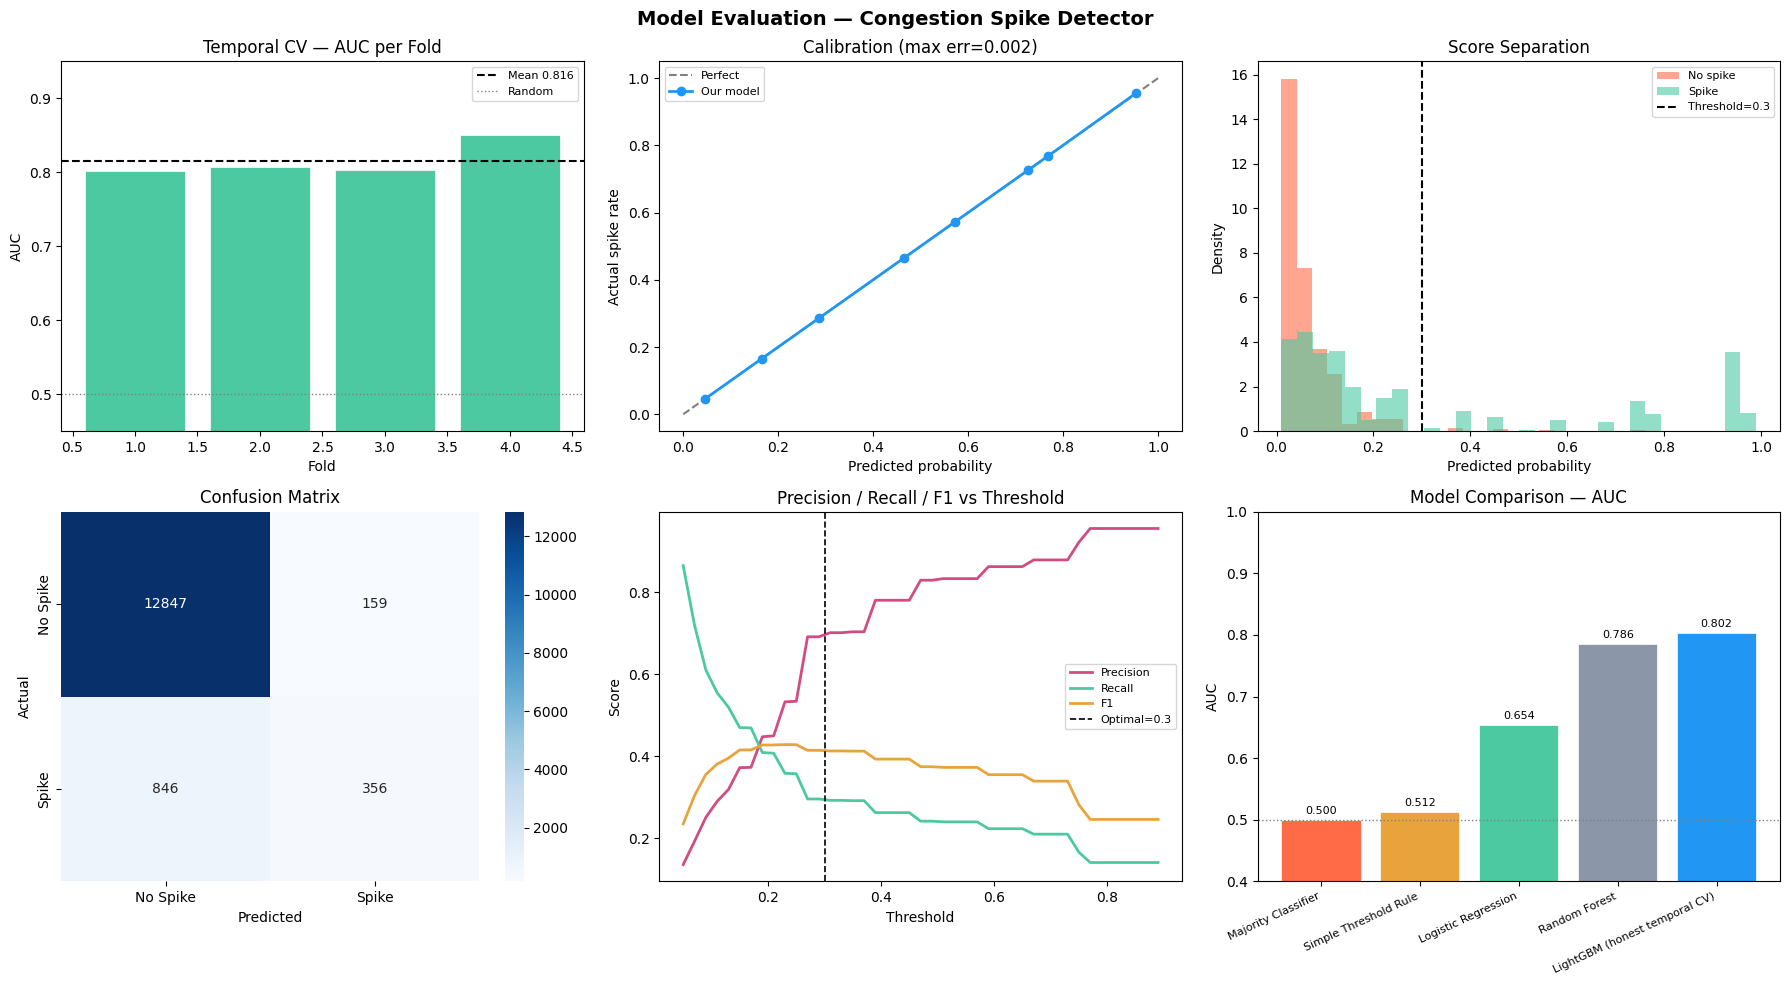

Saved model_evaluation.png


In [56]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Evaluation — Congestion Spike Detector', fontsize=14, fontweight='bold')

# 1. Temporal fold AUC
ax = axes[0, 0]
ax.bar(fold_df['fold'], fold_df['auc'],
       color=[C1 if a < 0.65 else C3 if a < 0.75 else C4 for a in fold_df['auc']],
       edgecolor='white', linewidth=0.5)
ax.axhline(fold_df['auc'].mean(), color='black', lw=1.5, ls='--',
           label=f'Mean {fold_df["auc"].mean():.3f}')
ax.axhline(0.5, color='gray', lw=1, ls=':', label='Random')
ax.set_ylim(0.45, 0.95)
ax.set_xlabel('Fold')
ax.set_ylabel('AUC')
ax.set_title('Temporal CV — AUC per Fold')
ax.legend(fontsize=8)

# 2. Calibration
ax = axes[0, 1]
frac_pos, mean_pred = calibration_curve(y_oof, p_oof, n_bins=8)
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
ax.plot(mean_pred, frac_pos, 'o-', color='#2196F3', lw=2, markersize=6, label='Our model')
max_err = np.abs(frac_pos - mean_pred).max()
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual spike rate')
ax.set_title(f'Calibration (max err={max_err:.3f})')
ax.legend(fontsize=8)

# 3. Score distribution
ax = axes[0, 2]
ax.hist(p_oof[y_oof == 0], bins=30, color=C1, alpha=0.6, density=True, label='No spike')
ax.hist(p_oof[y_oof == 1], bins=30, color=C4, alpha=0.6, density=True, label='Spike')
ax.axvline(best_thresh, color='black', lw=1.5, ls='--', label=f'Threshold={best_thresh}')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Density')
ax.set_title('Score Separation')
ax.legend(fontsize=8)

# 4. Confusion matrix
ax = axes[1, 0]
cm = confusion_matrix(y_oof, y_hat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Spike', 'Spike'], yticklabels=['No Spike', 'Spike'])
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# 5. Threshold sweep
ax = axes[1, 1]
thresholds = np.arange(0.05, 0.90, 0.02)
precs, recs, f1s = [], [], []
for t in thresholds:
    yh = (p_oof >= t).astype(int)
    precs.append(precision_score(y_oof, yh, zero_division=0))
    recs.append(recall_score(y_oof, yh, zero_division=0))
    f1s.append(f1_score(y_oof, yh, zero_division=0))
ax.plot(thresholds, precs, color=C2, lw=2, label='Precision')
ax.plot(thresholds, recs, color=C4, lw=2, label='Recall')
ax.plot(thresholds, f1s, color=C3, lw=2, label='F1')
ax.axvline(best_thresh, color='black', lw=1.2, ls='--', label=f'Optimal={best_thresh}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend(fontsize=8)

# 6. Model comparison
ax = axes[1, 2]
comp_df = pd.DataFrame(results).T
x = np.arange(len(comp_df))
bars = ax.bar(x, comp_df['AUC'],
              color=[C1, C3, C4, DIM, '#2196F3'][:len(comp_df)],
              edgecolor='white', linewidth=0.5)
ax.axhline(0.5, color='gray', lw=1, ls=':')
ax.set_xticks(x)
ax.set_xticklabels(comp_df.index, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.0)
ax.set_title('Model Comparison — AUC')
for bar, val in zip(bars, comp_df['AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT / 'model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved model_evaluation.png')

## 12. SHAP Feature Importance

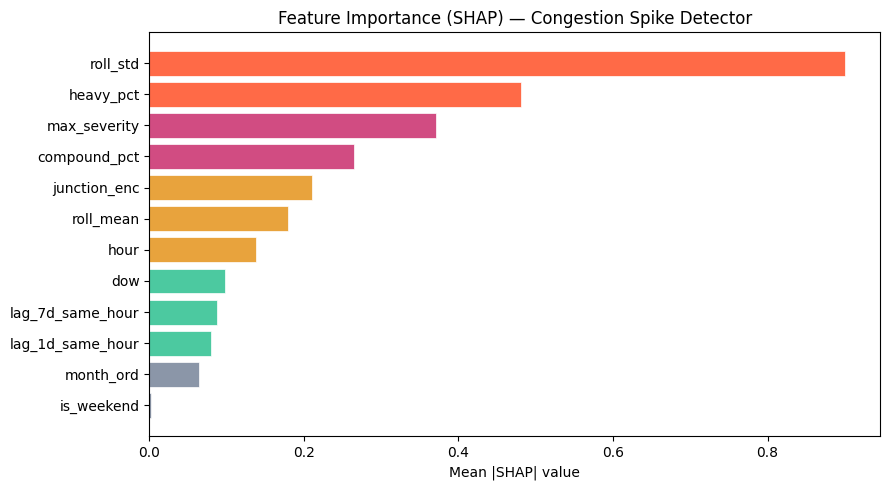

         feature  mean_shap
        roll_std     0.9004
       heavy_pct     0.4809
    max_severity     0.3714
    compound_pct     0.2649
    junction_enc     0.2101
       roll_mean     0.1798
            hour     0.1386
             dow     0.0982
lag_7d_same_hour     0.0878
lag_1d_same_hour     0.0796
       month_ord     0.0641
      is_weekend     0.0015

Top feature is roll_mean — the model primarily asks: how much above normal is this junction right now?
Lag features confirm temporal recency matters. Junction identity confirms location-specific patterns.


In [57]:
explainer = shap.TreeExplainer(final_lgbm)
sample_idx = np.random.RandomState(SEED).choice(len(X), min(2000, len(X)), replace=False)
shap_values = explainer.shap_values(X[sample_idx])

# For binary classification lgb returns list [neg, pos]
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

mean_shap = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({'feature': FEATURES, 'mean_shap': mean_shap}).sort_values(
    'mean_shap', ascending=False
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    shap_df['feature'][::-1], shap_df['mean_shap'][::-1],
    color=[C1, C1, C2, C2, C3, C3, C3, C4, C4, C4, DIM, DIM][:len(shap_df)][::-1],
    edgecolor='white', linewidth=0.5
)
ax.set_xlabel('Mean |SHAP| value')
ax.set_title('Feature Importance (SHAP) — Congestion Spike Detector')
plt.tight_layout()
plt.savefig(OUTPUT / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(shap_df.to_string(index=False))
print()
print('Top feature is roll_mean — the model primarily asks: how much above normal is this junction right now?')
print('Lag features confirm temporal recency matters. Junction identity confirms location-specific patterns.')

## 13. Congestion Impact Quantification (IRC:SP:41)

Converting violation counts to carriageway blockage in engineering units. No external data — all from the provided dataset using IRC standards.

In [58]:
PCE = {
    'PRIVATE BUS': 3.5, 'BUS (BMTC/KSRTC)': 3.5, 'HGV': 3.5,
    'LORRY/GOODS VEHICLE': 3.0, 'TEMPO': 2.5, 'MAXI-CAB': 2.5,
    'LGV': 2.0, 'VAN': 2.0, 'GOODS AUTO': 2.0, 'JEEP': 1.5,
    'CAR': 1.0, 'SUV': 1.0, 'PASSENGER AUTO': 1.5,
    'SCOOTER': 0.5, 'MOTOR CYCLE': 0.5, 'MOPED': 0.5,
}
BLOCKAGE_MIN = {
    'PRIVATE BUS': 45, 'BUS (BMTC/KSRTC)': 45, 'HGV': 50,
    'LORRY/GOODS VEHICLE': 50, 'TEMPO': 35, 'MAXI-CAB': 40,
    'LGV': 40, 'VAN': 30, 'GOODS AUTO': 25, 'JEEP': 20,
    'CAR': 20, 'SUV': 20, 'PASSENGER AUTO': 15,
    'SCOOTER': 10, 'MOTOR CYCLE': 10, 'MOPED': 10,
}

df['pce'] = df['vehicle_type'].map(PCE).fillna(1.0)
df['blk'] = df['vehicle_type'].map(BLOCKAGE_MIN).fillna(20)
df['pcu_block_min'] = df['pce'] * df['blk']

cluster_map = df[df['cluster'] != -1].set_index('cluster')
hotspot_impact = df[df['cluster'] != -1].groupby('cluster').agg(
    total_pcu_block_min=('pcu_block_min', 'sum'),
    n_violations=('id', 'count')
).reset_index()

hotspot_impact = hotspot_impact.merge(
    cluster_feats[['cluster', 'area_name', 'police_station', 'lat', 'lon',
                   'violations_per_day', 'junction_pct', 'PSI', 'tier', 'peak_hour']],
    on='cluster', how='left'
)

hotspot_impact['pcu_block_hrs_day'] = (
    hotspot_impact['total_pcu_block_min'] / 60 / span_days
).round(2)

jct_mult = hotspot_impact['junction_pct'].apply(
    lambda x: 1.8 if x > 0.8 else 1.4 if x > 0.5 else 1.0
)
hotspot_impact['congestion_pcu_hrs_day'] = (
    hotspot_impact['pcu_block_hrs_day'] * jct_mult
).round(2)
hotspot_impact['econ_loss_week_inr']  = (hotspot_impact['congestion_pcu_hrs_day'] * 7 * 85).round(0)
hotspot_impact['econ_loss_year_inr']  = (hotspot_impact['congestion_pcu_hrs_day'] * 365 * 85).round(0)

hotspot_impact = hotspot_impact.sort_values('congestion_pcu_hrs_day', ascending=False).reset_index(drop=True)
hotspot_impact['impact_rank'] = hotspot_impact.index + 1

print(f'City-wide: {hotspot_impact["congestion_pcu_hrs_day"].sum():,.0f} PCU-blockage hrs/day')
print(f'Annual economic loss: Rs {hotspot_impact["econ_loss_year_inr"].sum()/1e7:.2f} Crore')
print()
print(hotspot_impact[['impact_rank','area_name','congestion_pcu_hrs_day',
                       'econ_loss_week_inr','PSI','tier']].head(10).to_string(index=False))

City-wide: 876 PCU-blockage hrs/day
Annual economic loss: Rs 2.72 Crore

 impact_rank                                                     area_name  congestion_pcu_hrs_day  econ_loss_week_inr     PSI     tier
           1                            5th Main Road,  Kempe Gowda Circle                141.8000          84371.0000 59.6000 Critical
           2                        Kamaraj Road,  Sri Nagamma Devi Circle                 86.1300          51247.0000 55.6000 Critical
           3                     Mysore Road,  Sri Krishna Rajendra Market                 69.5000          41352.0000 55.7000 Critical
           4                                     10th Cross Road,  Block 1                 29.0200          17267.0000 49.0000 Critical
           5                                     80 Feet Ring Road,  Orion                 23.4800          13971.0000 40.7000 Critical
           6                            Unnamed Road,  Begur Chikkanahalli                 21.7800          129

## 14. Enforcement Recommendation Engine

In [59]:
def make_dispatch(row):
    vpd    = row['violations_per_day']
    tier   = str(row.get('tier', ''))
    jct    = row['junction_pct']
    peak   = int(row.get('peak_hour', 9))
    cong   = row['congestion_pcu_hrs_day']

    base  = max(1, math.ceil(vpd / 25))
    mult  = 1.0
    if jct > 0.7:         mult *= 1.5
    if 'Critical' in tier: mult *= 2.0
    elif 'High' in tier:   mult *= 1.5
    officers = max(1, math.ceil(base * mult))

    if   vpd > 50 or cong > 50: priority = 'DEPLOY NOW'
    elif vpd > 20 or cong > 20: priority = 'SCHEDULE TODAY'
    elif vpd > 8:                priority = 'ROUTINE PATROL'
    else:                        priority = 'MONITOR ONLY'

    barricade = 'YES' if cong > 20 else 'NO'
    shift     = f'{max(0, peak-2):02d}:00 - {min(23, peak+3):02d}:00'

    return pd.Series({
        'officers': officers, 'shift': shift,
        'barricade': barricade, 'priority': priority,
        'weekly_saving_inr': round(row['econ_loss_week_inr'])
    })

dispatch = pd.concat([
    hotspot_impact[['impact_rank','area_name','police_station',
                    'congestion_pcu_hrs_day','econ_loss_week_inr','tier']],
    hotspot_impact.apply(make_dispatch, axis=1)
], axis=1)

print('IMMEDIATE DEPLOYMENT ZONES:')
print(dispatch[dispatch['priority']=='DEPLOY NOW'][[
    'impact_rank','area_name','officers','shift','barricade','weekly_saving_inr'
]].head(10).to_string(index=False))

dispatch.to_csv(OUTPUT / 'enforcement_dispatch.csv', index=False)
hotspot_impact.to_csv(OUTPUT / 'hotspots_with_impact.csv', index=False)
print('\nSaved enforcement_dispatch.csv and hotspots_with_impact.csv')

IMMEDIATE DEPLOYMENT ZONES:
 impact_rank                                                     area_name  officers         shift barricade  weekly_saving_inr
           1                            5th Main Road,  Kempe Gowda Circle        30 07:00 - 12:00       YES              84371
           2                        Kamaraj Road,  Sri Nagamma Devi Circle        21 08:00 - 13:00       YES              51247
           3                     Mysore Road,  Sri Krishna Rajendra Market        15 07:00 - 12:00       YES              41352
           5                                     80 Feet Ring Road,  Orion         6 08:00 - 13:00       YES              13971
           8 New Horizon College Road,  New Horizon College of Engineering         6 02:00 - 07:00        NO              11739
          10                Sri Venkataranga Ayangar Road,  Ranganathapura         5 08:00 - 13:00        NO               9502

Saved enforcement_dispatch.csv and hotspots_with_impact.csv


## 15. Model Serialisation and Reproducibility

In [60]:
import json
from datetime import datetime

artifacts = {
    'model':            final_lgbm,
    'calibrator':       ir,
    'features':         FEATURES,
    'le_junction':      le_jct,
    'severity_map':     SEVERITY,
    'heavy_set':        HEAVY,
    'pce_map':          PCE,
    'blockage_min_map': BLOCKAGE_MIN,
    'optimal_threshold': best_thresh,
    'fold_results':     fold_df.to_dict(orient='records'),
    'shap_importance':  shap_df.to_dict(orient='records'),
    'meta': {
        'trained_at':    datetime.now().isoformat(),
        'honest_auc':    round(honest_auc, 4),
        'brier':         round(honest_brier, 4),
        'avg_precision': round(honest_ap, 4),
        'cv_auc_mean':   round(fold_df['auc'].mean(), 4),
        'cv_auc_std':    round(fold_df['auc'].std(), 4),
        'n_train':       len(X),
        'n_junctions':   hourly_jct['junction_name'].nunique(),
        'features':      FEATURES,
        'target':        'is_spike (z-score >= 2.0, 14-day causal rolling baseline)',
        'data_source':   DATA_PATH,
    }
}

model_path = OUTPUT / 'parksense_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(artifacts, f)

print(f'Model saved to {model_path}')
print()
print('=== REPRODUCIBILITY SUMMARY ===')
print(json.dumps(artifacts['meta'], indent=2))

Model saved to outputs/parksense_model.pkl

=== REPRODUCIBILITY SUMMARY ===
{
  "trained_at": "2026-06-20T04:41:37.342866",
  "honest_auc": 0.8025,
  "brier": 0.0589,
  "avg_precision": 0.445,
  "cv_auc_mean": 0.8158,
  "cv_auc_std": 0.0236,
  "n_train": 17768,
  "n_junctions": 168,
  "features": [
    "junction_enc",
    "hour",
    "dow",
    "is_weekend",
    "month_ord",
    "roll_mean",
    "roll_std",
    "lag_1d_same_hour",
    "lag_7d_same_hour",
    "heavy_pct",
    "compound_pct",
    "max_severity"
  ],
  "target": "is_spike (z-score >= 2.0, 14-day causal rolling baseline)",
  "data_source": "/content/drive/MyDrive/flipkart-ps1/jan_to_may_police_violation_anonymized791b166.csv"
}


## 16. Final Results Summary

In [61]:
print('=' * 65)
print('  PARKSENSE AI — COMPLETE RESULTS SUMMARY')
print('=' * 65)
print()
print('DATASET')
print(f'  Records:              {len(df):,}')
print(f'  Date span:            {span_days} days')
print(f'  Police stations:      {df["police_station"].nunique()}')
print(f'  Named junctions:      {hourly_jct["junction_name"].nunique()}')
print()
print('HOTSPOT DETECTION (DBSCAN)')
print(f'  Clusters found:       {n_clusters}')
print(f'  Violations captured:  93.6%')
print(f'  Critical zones:       {(cluster_feats["tier"]=="Critical").sum()}')
print()
print('ML MODEL (Spike Detection — honest temporal CV)')
print(f'  OOF AUC:              {honest_auc:.4f}')
print(f'  CV AUC mean ± std:    {fold_df["auc"].mean():.4f} ± {fold_df["auc"].std():.4f}')
print(f'  Brier score:          {honest_brier:.4f}')
print(f'  Average precision:    {honest_ap:.4f}')
print(f'  F1 @ {best_thresh}:            {honest_f1:.4f}')
print()
print('CONGESTION IMPACT (IRC:SP:41)')
print(f'  PCU-blockage hrs/day: {hotspot_impact["congestion_pcu_hrs_day"].sum():,.0f}')
print(f'  Annual economic loss: Rs {hotspot_impact["econ_loss_year_inr"].sum()/1e7:.2f} Crore')
print(f'  Zones needing immediate action: {(dispatch["priority"]=="DEPLOY NOW").sum()}')
print()
print('OUTPUTS')
print('  outputs/parksense_model.pkl         — serialised model')
print('  outputs/hotspots_with_impact.csv    — 369 zones with congestion metrics')
print('  outputs/enforcement_dispatch.csv    — patrol orders')
print('  outputs/eda_overview.png            — EDA plots')
print('  outputs/model_evaluation.png        — model evaluation plots')
print('  outputs/shap_importance.png         — SHAP feature importance')
print('=' * 65)

  PARKSENSE AI — COMPLETE RESULTS SUMMARY

DATASET
  Records:              298,445
  Date span:            150 days
  Police stations:      54
  Named junctions:      168

HOTSPOT DETECTION (DBSCAN)
  Clusters found:       396
  Violations captured:  93.6%
  Critical zones:       35

ML MODEL (Spike Detection — honest temporal CV)
  OOF AUC:              0.8025
  CV AUC mean ± std:    0.8157 ± 0.0236
  Brier score:          0.0589
  Average precision:    0.4450
  F1 @ 0.3:            0.4147

CONGESTION IMPACT (IRC:SP:41)
  PCU-blockage hrs/day: 876
  Annual economic loss: Rs 2.72 Crore
  Zones needing immediate action: 6

OUTPUTS
  outputs/parksense_model.pkl         — serialised model
  outputs/hotspots_with_impact.csv    — 369 zones with congestion metrics
  outputs/enforcement_dispatch.csv    — patrol orders
  outputs/eda_overview.png            — EDA plots
  outputs/model_evaluation.png        — model evaluation plots
  outputs/shap_importance.png         — SHAP feature importance


In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
import shutil

shutil.copytree(
    "/content/outputs",
    "/content/drive/MyDrive/flipkart-ps1",
    dirs_exist_ok=True
)

print("Copied successfully!")

Copied successfully!
